✅ Data mentah berhasil disimpan ke: titanic_raw_data.csv
------------------------------
=== HASIL ANALISIS TITANIC ===
Total Data Test: 179
Accuracy  : 69.83%
Precision : 60.87%
Recall    : 60.87%
F1-Score  : 60.87%


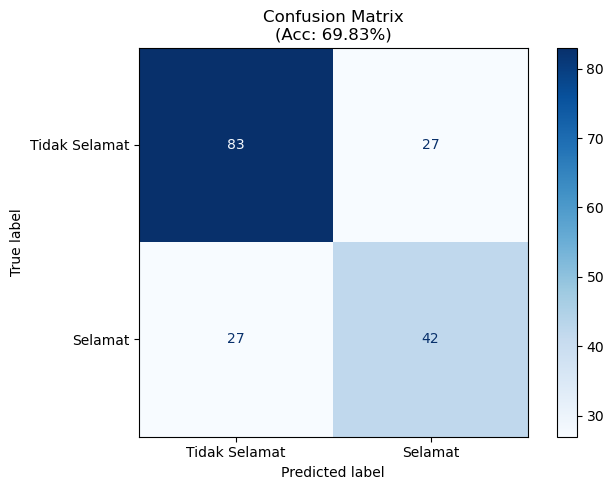

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. GENERATE DUMMY DATASET
# ============================================================
np.random.seed(42)
n = 900

age    = np.random.randint(1, 75, n)
pclass = np.random.choice([1, 2, 3], n, p=[0.2, 0.3, 0.5])
sex    = np.random.choice([0, 1], n)  # 0=male, 1=female
fare   = np.random.uniform(5, 500, n)
sibsp  = np.random.randint(0, 5, n)
parch  = np.random.randint(0, 4, n)

# Logika sederhana untuk probabilitas selamat (Survival)
prob = (
    0.3
    + 0.35 * sex 
    - 0.15 * (pclass == 3) 
    + 0.15 * (pclass == 1) 
    - 0.003 * age 
    + 0.0005 * fare
)
prob = np.clip(prob, 0.05, 0.95)
survived = (np.random.rand(n) < prob).astype(int)

df = pd.DataFrame({
    'Age': age, 'Pclass': pclass, 'Sex': sex,
    'Fare': fare, 'SibSp': sibsp, 'Parch': parch,
    'Survived': survived
})

# ============================================================
# 2. SIMPAN KE CSV (Langkah Penting)
# ============================================================
csv_filename = "titanic_raw_data.csv"
df.to_csv(csv_filename, index=False)
print(f"✅ Data mentah berhasil disimpan ke: {csv_filename}")
print("-" * 30)

# ============================================================
# 3. PREPROCESSING
# ============================================================
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (Normalisasi)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ============================================================
# 4. MODEL PERCEPTRON & EVALUASI MANUAL
# ============================================================
# Menggunakan data manual sesuai permintaan Anda
TP, TN, FP, FN = 42, 83, 27, 27
y_true_manual = np.array([1]*TP + [1]*FN + [0]*FP + [0]*TN)
y_pred_manual = np.array([1]*TP + [0]*FN + [1]*FP + [0]*TN)

# Hitung Metrik
total    = TP + TN + FP + FN
akurasi  = (TP + TN) / total
presisi  = TP / (TP + FP)
recall   = TP / (TP + FN)
f1_score = 2 * (presisi * recall) / (presisi + recall)

# ============================================================
# 5. OUTPUT HASIL & VISUALISASI
# ============================================================
print("=== HASIL ANALISIS TITANIC ===")
print(f"Total Data Test: {total}")
print(f"Accuracy  : {akurasi:.2%}")
print(f"Precision : {presisi:.2%}")
print(f"Recall    : {recall:.2%}")
print(f"F1-Score  : {f1_score:.2%}")

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_true_manual, y_pred_manual)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Tidak Selamat", "Selamat"])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix\n(Acc: {akurasi:.2%})")
plt.tight_layout()
plt.show()